In [39]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import plotly.express as px


In [40]:
df = pd.read_csv('1730285881-Airbnb_Open_Data.csv')

C:\Users\hp\AppData\Local\Temp\ipykernel_740\253668019.py:1: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('1730285881-Airbnb_Open_Data.csv')


In [41]:
print(df.head())

        id                                              NAME      host id  \
0  1001254                Clean & quiet apt home by the park  80014485718   
1  1002102                             Skylit Midtown Castle  52335172823   
2  1002403               THE VILLAGE OF HARLEM....NEW YORK !  78829239556   
3  1002755                                               NaN  85098326012   
4  1003689  Entire Apt: Spacious Studio/Loft by central park  92037596077   

  host_identity_verified host name neighbourhood group neighbourhood  \
0            unconfirmed  Madaline            Brooklyn    Kensington   
1               verified     Jenna           Manhattan       Midtown   
2                    NaN     Elise           Manhattan        Harlem   
3            unconfirmed     Garry            Brooklyn  Clinton Hill   
4               verified    Lyndon           Manhattan   East Harlem   

        lat      long        country  ... service fee minimum nights  \
0  40.64749 -73.97237  United St

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              102599 non-null  int64  
 1   NAME                            102349 non-null  object 
 2   host id                         102599 non-null  int64  
 3   host_identity_verified          102310 non-null  object 
 4   host name                       102193 non-null  object 
 5   neighbourhood group             102570 non-null  object 
 6   neighbourhood                   102583 non-null  object 
 7   lat                             102591 non-null  float64
 8   long                            102591 non-null  float64
 9   country                         102067 non-null  object 
 10  country code                    102468 non-null  object 
 11  instant_bookable                102494 non-null  object 
 12  cancellation_pol

In [43]:
df.duplicated().value_counts()

False    102058
True        541
Name: count, dtype: int64

In [44]:
print(df[df.duplicated()])

              id                                              NAME  \
102058  35506831    Master Bedroom with private Bathroom & Balcony   
102059  35507383                Cozy 2 br in sunny Fort Greene apt   
102060  35507935               Duplex w/ Terrace @ Box House Hotel   
102061  35508488      Cozy, clean Greenpoint room with yard access   
102062  35509040  2BR XL Loft: Cleaning CDC guidelines implemented   
...          ...                                               ...   
102594   6092437                        Spare room in Williamsburg   
102595   6092990                     Best Location near Columbia U   
102596   6093542                    Comfy, bright room in Brooklyn   
102597   6094094                  Big Studio-One Stop from Midtown   
102598   6094647                              585 sf Luxury Studio   

            host id host_identity_verified            host name  \
102058  55110690425            unconfirmed               UZeyir   
102059  80193772189      

In [45]:
df = df.drop_duplicates()

In [46]:
df.duplicated().value_counts()

False    102058
Name: count, dtype: int64

In [47]:
df.drop(['house_rules', 'license'], axis=1, inplace=True)


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 102058 entries, 0 to 102057
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              102058 non-null  int64  
 1   NAME                            101808 non-null  object 
 2   host id                         102058 non-null  int64  
 3   host_identity_verified          101769 non-null  object 
 4   host name                       101654 non-null  object 
 5   neighbourhood group             102029 non-null  object 
 6   neighbourhood                   102042 non-null  object 
 7   lat                             102050 non-null  float64
 8   long                            102050 non-null  float64
 9   country                         101526 non-null  object 
 10  country code                    101927 non-null  object 
 11  instant_bookable                101953 non-null  object 
 12  cancellation_policy  

In [49]:

df['price'] = df['price'].str.replace('$','', regex=False)
df['service fee'] = df['service fee'].str.replace('$','', regex=False)

In [50]:

df['price'] = df['price'].str.replace(',','', regex=False)
df['service fee'] = df['service fee'].str.replace(',','', regex=False)

In [51]:
df.rename(columns={'price':'price_$',
                   'service fee': 'service_fee_$'}, inplace=True)

In [52]:
df['price_$'] = df['price_$'].astype(float)
df['service_fee_$'] = df['service_fee_$'].astype(float)
df['id'] = df['id'].astype(str)
df['host id'] = df['host id'].astype(str)
df['last review'] = pd.to_datetime(df['last review'])
df['Construction year'] = df['Construction year'].astype(float)
df['host_identity_verified'] = df['host_identity_verified'].astype(str)

In [53]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 102058 entries, 0 to 102057
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   id                              102058 non-null  object        
 1   NAME                            101808 non-null  object        
 2   host id                         102058 non-null  object        
 3   host_identity_verified          102058 non-null  object        
 4   host name                       101654 non-null  object        
 5   neighbourhood group             102029 non-null  object        
 6   neighbourhood                   102042 non-null  object        
 7   lat                             102050 non-null  float64       
 8   long                            102050 non-null  float64       
 9   country                         101526 non-null  object        
 10  country code                    101927 non-null  object      

In [54]:
df.loc[df['neighbourhood group'] == 'brookln', 'neighbourhood group'] = 'Brooklyn'

In [55]:
Q1 = df['price_$'].quantile(0.25)
Q3 = df['price_$'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['price_$'] < (Q1 - 1.5 * IQR)) | (df['price_$'] > (Q3 + 1.5 * IQR))]
print(outliers)

Empty DataFrame
Columns: [id, NAME, host id, host_identity_verified, host name, neighbourhood group, neighbourhood, lat, long, country, country code, instant_bookable, cancellation_policy, room type, Construction year, price_$, service_fee_$, minimum nights, number of reviews, last review, reviews per month, review rate number, calculated host listings count, availability 365]
Index: []

[0 rows x 24 columns]


In [56]:
filtered_df = df[(df['calculated host listings count'] <= 500) & (df['availability 365'] <= 500)]

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 102058 entries, 0 to 102057
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   id                              102058 non-null  object        
 1   NAME                            101808 non-null  object        
 2   host id                         102058 non-null  object        
 3   host_identity_verified          102058 non-null  object        
 4   host name                       101654 non-null  object        
 5   neighbourhood group             102029 non-null  object        
 6   neighbourhood                   102042 non-null  object        
 7   lat                             102050 non-null  float64       
 8   long                            102050 non-null  float64       
 9   country                         101526 non-null  object        
 10  country code                    101927 non-null  object      

In [58]:
df.describe()

,lat,long,Construction year,price_$,service_fee_$,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365
count,102050.000000,102050.000000,101844.000000,101811.000000,101785.000000,101658.000000,101875.000000,86226,86240.000000,101739.000000,101739.000000,101610.000000
mean,40.728097,-73.949652,2012.488090,625.355580,125.039249,8.126640,27.517948,2019-06-11 02:12:22.996312064,1.375408,3.278733,7.936937,141.043992
min,40.499790,-74.249840,2003.000000,50.000000,10.000000,-1223.000000,0.000000,2012-07-11 00:00:00,0.010000,1.000000,1.000000,-10.000000
25%,40.688730,-73.982580,2007.000000,340.000000,68.000000,2.000000,1.000000,2018-10-27 00:00:00,0.220000,2.000000,1.000000,3.000000
50%,40.722290,-73.954440,2012.000000,625.000000,125.000000,3.000000,7.000000,2019-06-13 00:00:00,0.740000,3.000000,1.000000,96.000000
75%,40.762760,-73.932350,2017.000000,913.000000,183.000000,5.000000,31.000000,2019-07-05 00:00:00,2.010000,4.000000,2.000000,268.000000
max,40.916970,-73.705220,2022.000000,1200.000000,240.000000,5645.000000,1024.000000,2058-06-16 00:00:00,90.000000,5.000000,332.000000,3677.000000
std,0.055852,0.049502,5.765838,331.672649,66.325905,30.616698,49.571744,NaN,1.748019,1.285089,32.266355,135.429156


In [59]:
property_types = df['room type'].value_counts().to_frame()
print(property_types)

                 count
room type             
Entire home/apt  53429
Private room     46306
Shared room       2208
Hotel room         115


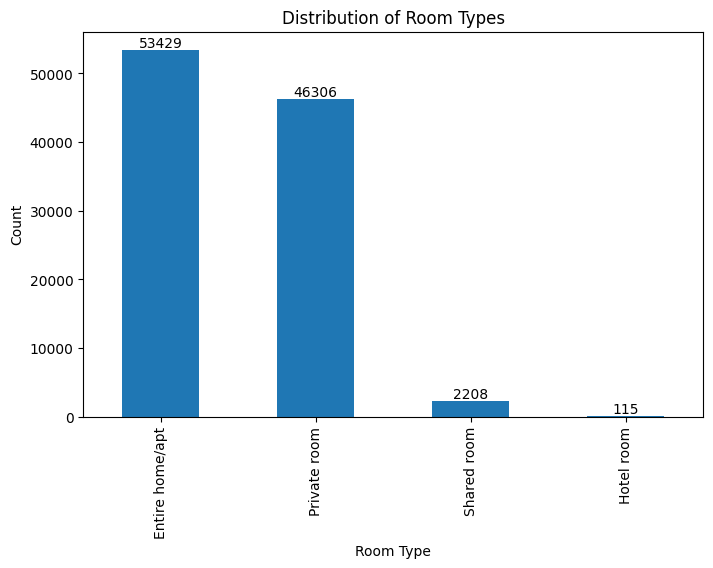

In [60]:
room_counts = df['room type'].value_counts()
plt.figure(figsize=(8,5))
ax = room_counts.plot(kind='bar')
plt.xlabel('Room Type')
plt.ylabel('Count')
plt.title('Distribution of Room Types')


for i, count in enumerate(room_counts):
    ax.text(i, count + 2, str(count), ha='center', va='bottom', fontsize=10)

plt.show()

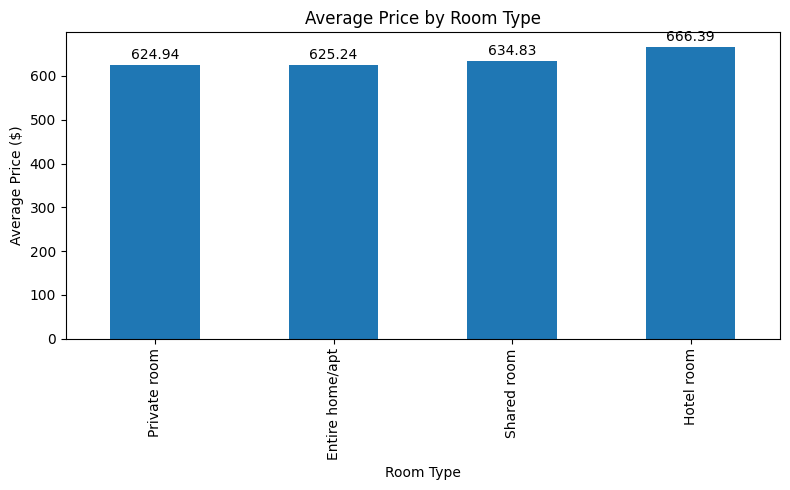

In [61]:

avg_price = df.groupby('room type')['price_$'].mean().sort_values()
plt.figure(figsize=(8,5))
ax = avg_price.plot(kind='bar', color='C0')
plt.xlabel('Room Type')
plt.ylabel('Average Price ($)')
plt.title('Average Price by Room Type')
for i, v in enumerate(avg_price):
    ax.text(i, v + max(avg_price)*0.01, f'{v:.2f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()



In [62]:
hood_group_counts = df['neighbourhood group'].value_counts().to_frame()
print(hood_group_counts)

                     count
neighbourhood group       
Manhattan            43557
Brooklyn             41631
Queens               13197
Bronx                 2694
Staten Island          949
manhatan                 1


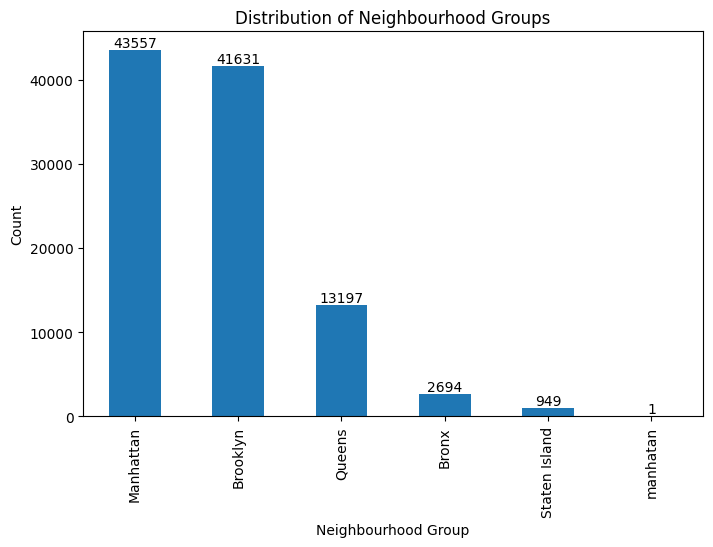

In [63]:
hood_group_counts = df['neighbourhood group'].value_counts()
plt.figure(figsize=(8,5))
ax = hood_group_counts.plot(kind='bar')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Count')
plt.title('Distribution of Neighbourhood Groups')


for i, count in enumerate(hood_group_counts):
    ax.text(i, count + 2, str(count), ha='center', va='bottom', fontsize=10)

plt.show()

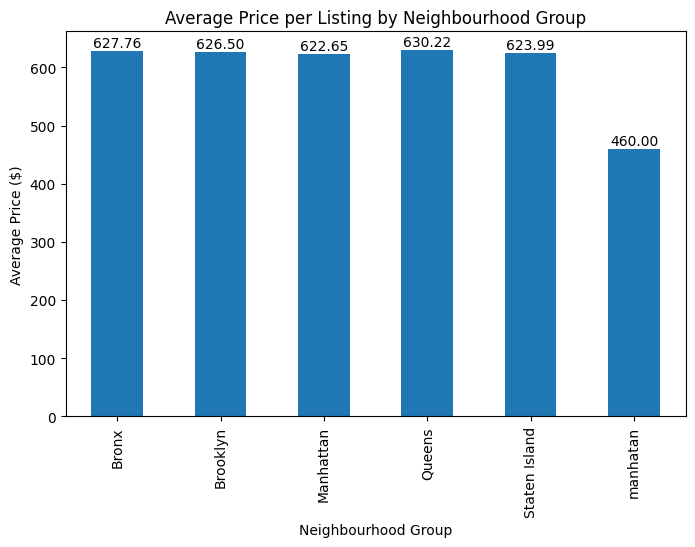

In [64]:
avg_price_per_group = df.groupby('neighbourhood group')['price_$'].mean()
plt.figure(figsize=(8,5))
ax = avg_price_per_group.plot(kind='bar')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Average Price ($)')
plt.title('Average Price per Listing by Neighbourhood Group')


for i, price in enumerate(avg_price_per_group):
    ax.text(i, price + 2, f'{price:.2f}', ha='center', va='bottom', fontsize=10)

plt.show()

Text(0.5, 1.0, 'Average Price vs Construction Year')

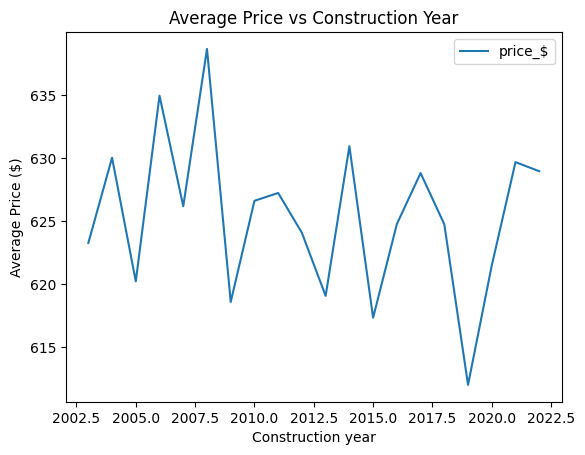

In [65]:
df.groupby(df['Construction year'])['price_$'].mean().to_frame().plot()
plt.xlabel('Construction year')
plt.ylabel('Average Price ($)')
plt.title('Average Price vs Construction Year')


Text(0.5, 1.0, 'Top 10 Hosts by Calculated Host Listings Count')

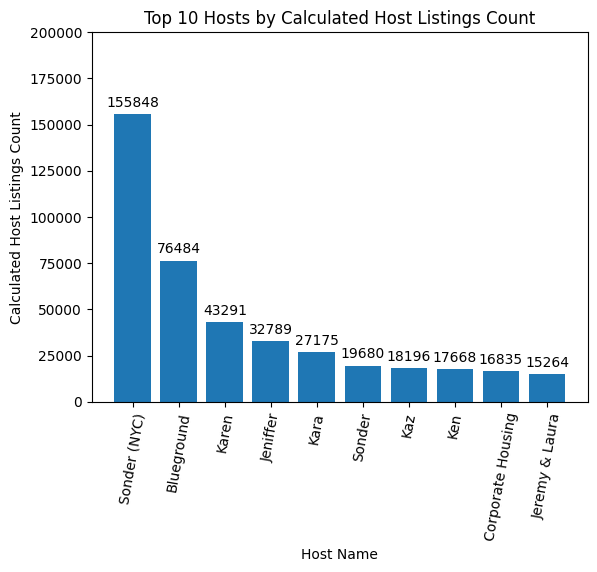

In [66]:
hosts = df.groupby('host name')['calculated host listings count'].sum().sort_values(ascending = False).nlargest(10).to_frame()
hosts_bar = plt.bar(hosts.index, hosts.loc[:, 'calculated host listings count'])
plt.bar_label(hosts_bar, label = hosts.loc[:, 'calculated host listings count'], padding = 3)
plt.xlabel('Host Name')
plt.ylabel('Calculated Host Listings Count')
plt.xticks(rotation = 80)
plt.ylim([0, 200000])
plt.title('Top 10 Hosts by Calculated Host Listings Count')

In [67]:
review = df.groupby('host_identity_verified')['review rate number'].mean().sort_values(ascending = False).to_frame()
print(review)

                        review rate number
host_identity_verified                    
verified                          3.285675
unconfirmed                       3.272033
nan                               3.236364


Text(0.5, 1.0, 'Average review Rate for each Verification Statistics')

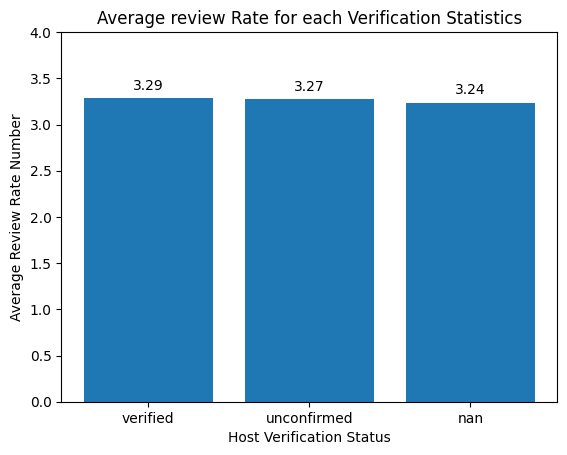

In [68]:
review_bar = plt.bar(review.index, review.loc[:, 'review rate number'])
plt.bar_label(review_bar, labels = round(review.loc[:, 'review rate number'], 2), padding = 4)
plt.ylim([0, 4])
plt.xlabel('Host Verification Status')
plt.ylabel('Average Review Rate Number')
plt.title('Average review Rate for each Verification Statistics')

Text(0.5, 1.0, 'Average Review Rate for each Verification Status')

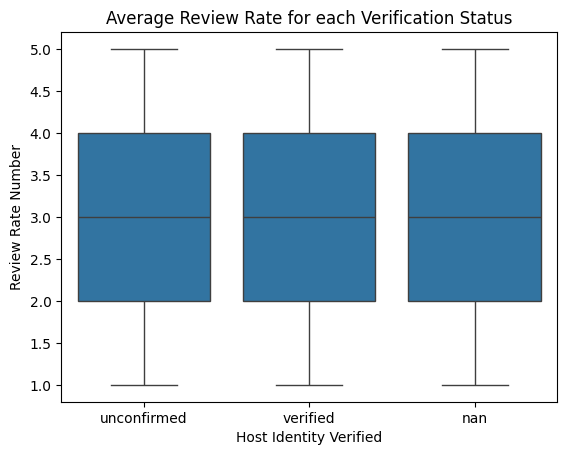

In [69]:
base_color = sns.color_palette()[0]
sns.boxplot(data = df, x = 'host_identity_verified', y = 'review rate number', color=base_color)
plt.xlabel('Host Identity Verified')
plt.ylabel('Review Rate Number')
plt.title('Average Review Rate for each Verification Status')

In [70]:
df['price_$'].corr(df['service_fee_$'])

np.float64(0.9999908754521187)

Text(0.5, 1.0, 'A regression plot showing the correlation of the price a listing and its srvice fee')

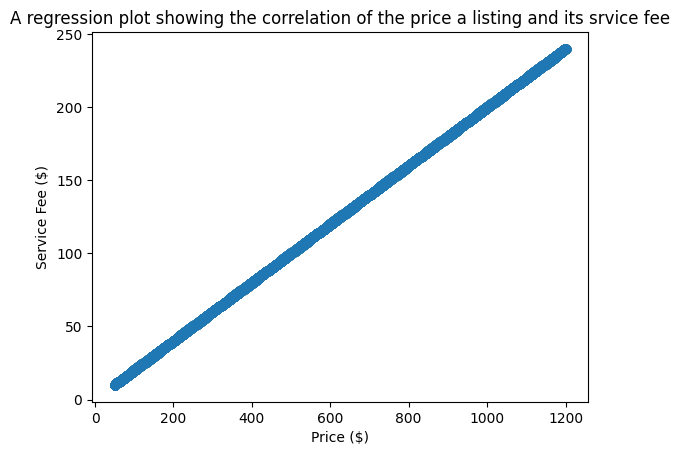

In [71]:
sns.regplot(df, x = 'price_$', y = 'service_fee_$')
plt.xlabel('Price ($)')
plt.ylabel('Service Fee ($)')   
plt.title('A regression plot showing the correlation of the price a listing and its srvice fee')


In [72]:
ARRN = df.groupby(['neighbourhood group', 'room type'])['review rate number'].mean().to_frame()
print(ARRN)

                                     review rate number
neighbourhood group room type                          
Bronx               Entire home/apt            3.346154
                    Private room               3.326873
                    Shared room                3.260870
Brooklyn            Entire home/apt            3.249963
                    Hotel room                 3.857143
                    Private room               3.263716
                    Shared room                3.334957
Manhattan           Entire home/apt            3.275869
                    Hotel room                 3.500000
                    Private room               3.277448
                    Shared room                3.254199
Queens              Entire home/apt            3.349306
                    Hotel room                 3.750000
                    Private room               3.315584
                    Shared room                3.369748
Staten Island       Entire home/apt            3

Text(0.5, 1.0, 'Average Review Rate for each room/property type in each neighbourhood group')

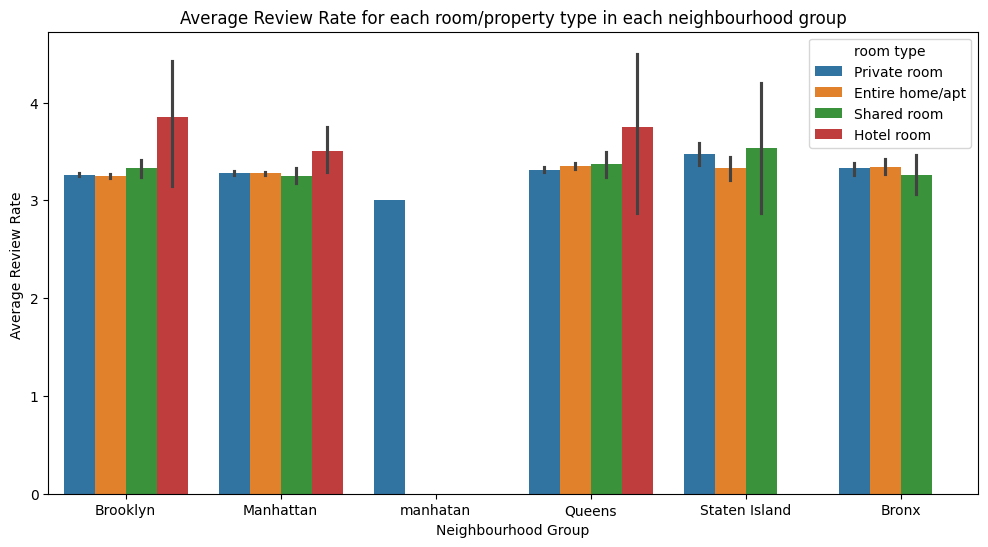

In [73]:
plt.figure(figsize=(12,6))
sns.barplot(data = df, x = 'neighbourhood group', y = 'review rate number', hue = 'room type')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Average Review Rate ')
plt.title('Average Review Rate for each room/property type in each neighbourhood group')

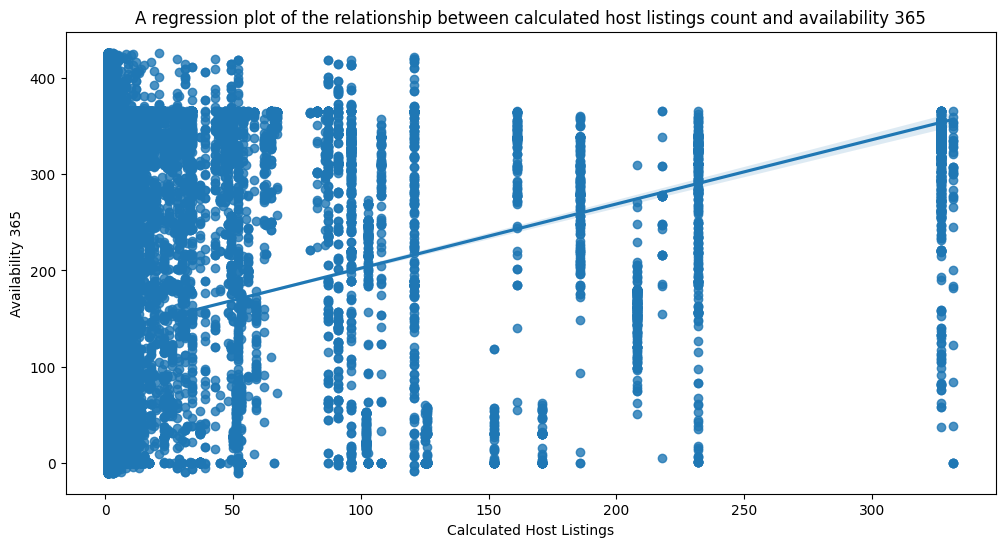

In [74]:

plt.figure(figsize=(12,6))
sns.regplot(data=filtered_df, x='calculated host listings count', y='availability 365')
plt.xlabel('Calculated Host Listings')
plt.ylabel('Availability 365')
plt.title('A regression plot of the relationship between calculated host listings count and availability 365')
plt.show()

In [75]:
df['calculated host listings count'].corr(df['availability 365'])

np.float64(0.15900516938193265)